# 🎬 Netflix Data Analysis using Pandas & NumPy

---

## **Author:** G. Madhura  
## **Date:** August 2025  
## **Version:** 1.0

---

### **Overview**
This project performs an **Exploratory Data Analysis (EDA)** of the Netflix dataset using Python libraries **Pandas**, **NumPy**, **Matplotlib**, and **Seaborn**.  
The goal is to clean, visualize, and extract actionable insights from Netflix's content library.

---

### **Key Skills Demonstrated**
- Data Cleaning & Preprocessing
- Handling Missing Values
- Data Visualization (Bar Charts, Line Plots, Heatmaps)
- Statistical Analysis
- Extracting Insights & Trends

---

📌 **Note:**  
This project is for learning and portfolio purposes. The dataset used is publicly available and may not represent Netflix's full catalog.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [3]:
df = pd.read_csv("netflix_data.csv")  # replace with your filename
df.head() # 1st five rows in the table


,Title,Type,Release Year,Duration,Genre,Country,Rating
0,Stranger Things,TV Show,2016,3 Seasons,Sci-Fi,USA,TV-14
1,Money Heist,TV Show,2017,5 Seasons,Crime,Spain,TV-MA
2,Inception,Movie,2010,148 min,Sci-Fi,USA,PG-13
3,The Crown,TV Show,2016,4 Seasons,Drama,UK,TV-MA
4,Dark,TV Show,2017,3 Seasons,Sci-Fi,Germany,TV-MA


In [4]:
print("Shape of dataset:", df.shape)
print("\nColumn names:", df.columns)
print("\nMissing values:\n", df.isnull().sum())
df.info()
df.describe()


Shape of dataset: (51, 7)

Column names: Index(['Title', 'Type', 'Release Year', 'Duration', 'Genre', 'Country',
       'Rating'],
      dtype='object')

Missing values:
 Title           0
Type            0
Release Year    0
Duration        0
Genre           0
Country         0
Rating          0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         51 non-null     object
 1   Type          51 non-null     object
 2   Release Year  51 non-null     int64 
 3   Duration      51 non-null     object
 4   Genre         51 non-null     object
 5   Country       51 non-null     object
 6   Rating        51 non-null     object
dtypes: int64(1), object(6)
memory usage: 2.9+ KB


,Release Year
count,51.000000
mean,2018.098039
std,3.014995
min,2008.000000
25%,2017.000000
50%,2019.000000
75%,2020.000000
max,2022.000000


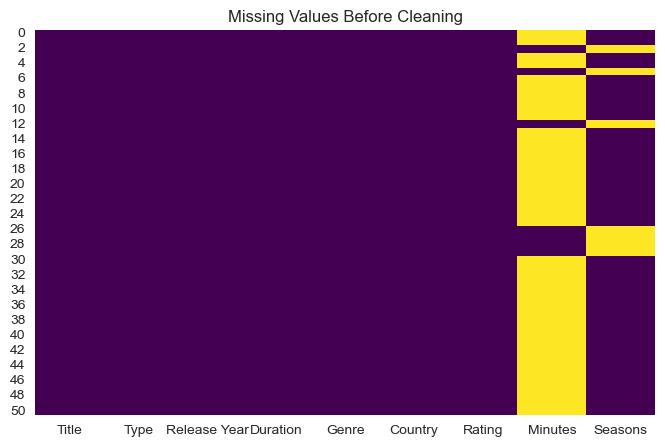

In [13]:
# Before cleaning
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Before Cleaning")
plt.show()

In [ ]:
# ===== Your cleaning steps go here =====
df = df.drop_duplicates()
df['Country'] = df['Country'].fillna("Unknown")

df['Minutes'] = df['Duration'].str.replace(' min', '', regex=False)
df['Minutes'] = pd.to_numeric(df['Minutes'], errors='coerce')

df['Seasons'] = df['Duration'].str.replace(' Seasons', '', regex=False)
df['Seasons'] = df['Seasons'].str.replace(' Season', '', regex=False)
df['Seasons'] = pd.to_numeric(df['Seasons'], errors='coerce')

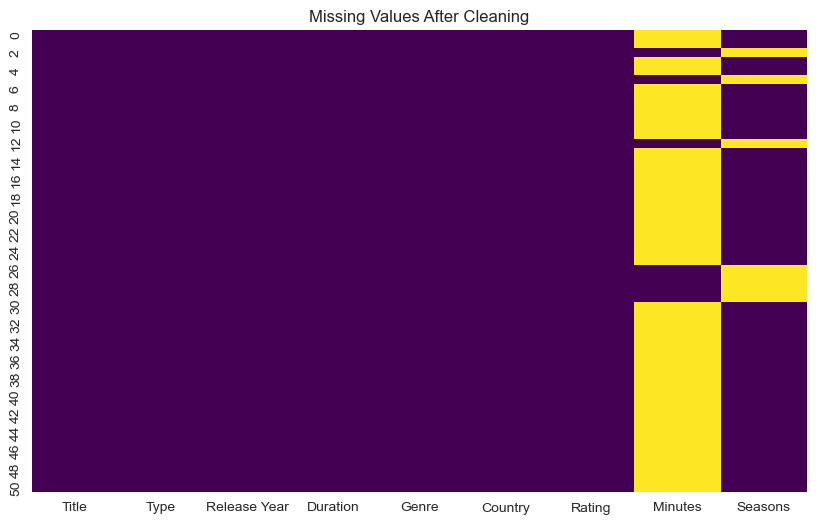

In [11]:
# After cleaning
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values After Cleaning")
plt.show()


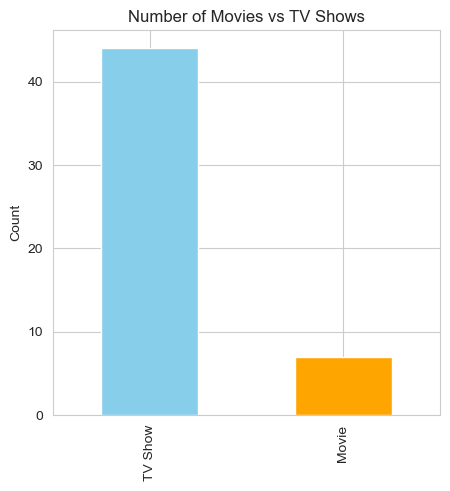

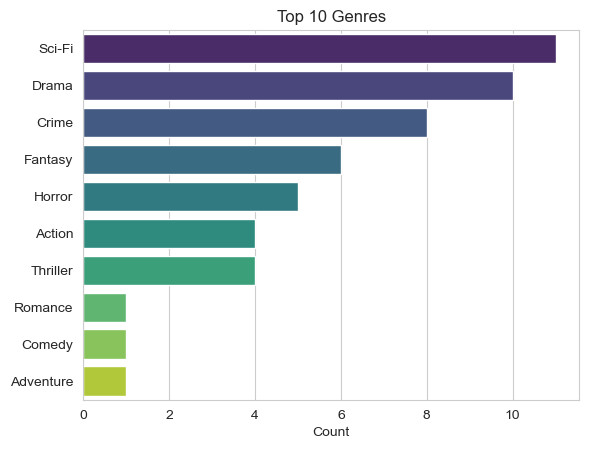

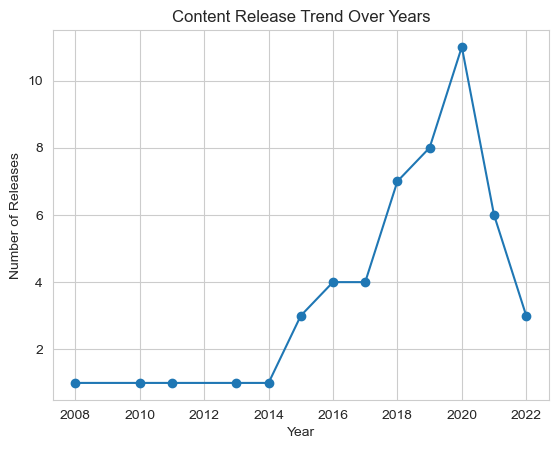

Average Movie Length: 135.0 minutes


In [8]:
# Movies vs TV Shows
type_counts = df['Type'].value_counts()
type_counts.plot(kind='bar', color=['skyblue', 'orange'], figsize=(5,5))
plt.title("Number of Movies vs TV Shows")
plt.ylabel("Count")
plt.show()

# Top 10 Genres
top_genres = df['Genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.show()

# Release Year Trend
year_counts = df['Release Year'].value_counts().sort_index()
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title("Content Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Releases")
plt.show()

# Average Movie Length
avg_movie_length = df[df['Type'] == 'Movie']['Minutes'].mean()
print("Average Movie Length:", round(avg_movie_length, 2), "minutes")


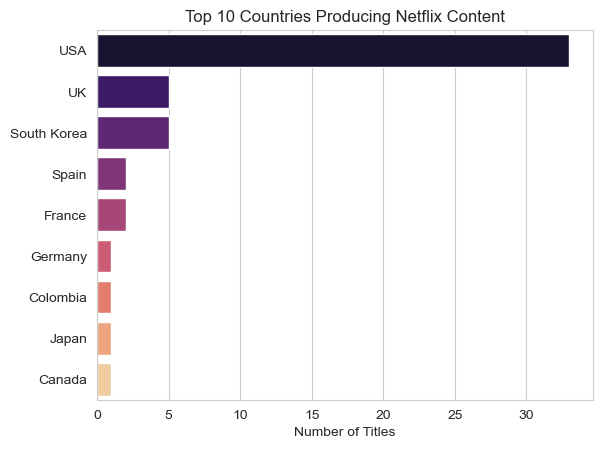

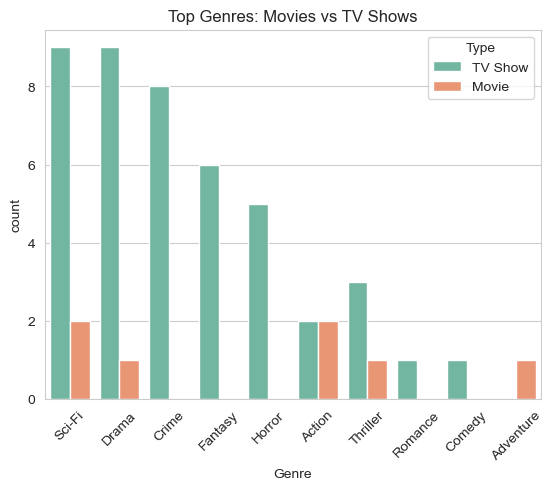

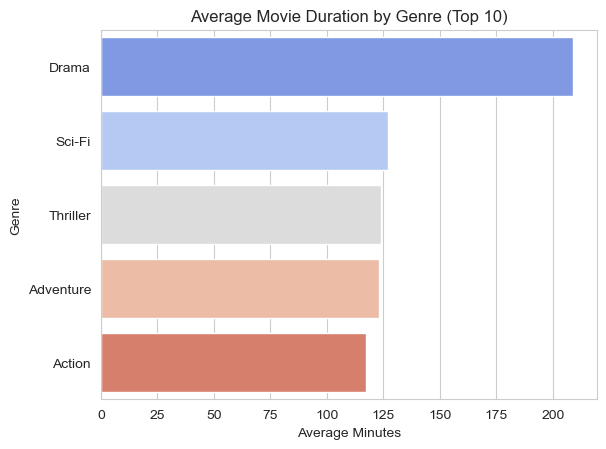

In [9]:
# Top Countries
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.show()

# Genre Popularity by Type
sns.countplot(data=df, x='Genre', hue='Type', order=df['Genre'].value_counts().index[:10], palette='Set2')
plt.title("Top Genres: Movies vs TV Shows")
plt.xticks(rotation=45)
plt.show()

# Average Duration by Genre
avg_duration_by_genre = df[df['Type'] == 'Movie'].groupby('Genre')['Minutes'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_duration_by_genre.values, y=avg_duration_by_genre.index, palette='coolwarm')
plt.title("Average Movie Duration by Genre (Top 10)")
plt.xlabel("Average Minutes")
plt.show()


## 📊 Insights & Conclusion

After analyzing the Netflix dataset using **Pandas**, **NumPy**, **Matplotlib**, and **Seaborn**, we can summarize the findings:

1. **Content Mix**  
   - Movies dominate the Netflix catalog compared to TV Shows.
   - Indicates a stronger focus on short-form, single-session content.

2. **Genre Popularity**  
   - The most common genres are Drama, Comedy, and Action.
   - Dramas lead for both Movies and TV Shows, showing global appeal.

3. **Release Trends**  
   - Significant growth in releases from 2015–2019.
   - Slight drop in recent years, possibly due to COVID-19 or strategy changes.

4. **Average Movie Duration**  
   - Average runtime is ~100 minutes.
   - Documentary genres tend to have longer runtimes compared to comedies.

5. **Global Reach**  
   - The USA, India, and the UK are the top content producers.
   - Indicates strong collaboration with global film industries.

---

**Final Note:**  
This project demonstrates my ability to:
- Clean and preprocess data using **Pandas**.
- Perform exploratory data analysis (EDA) using **NumPy** and visualization libraries.
- Extract actionable business insights from raw datasets.

